# Goal 1: Pre Processing and Data Exploration 

In [1]:
import os
import sys
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [2]:

sys.path.append(str(Path.cwd().parent))  # Add src to path
from src.data.loader import load_data
from src.utils import get_logger, load_config
# ── Cell: imports ─────────────────────────────────────────────────────────────
from src.data.preprocessor import (
    preprocess, nan_summary, bin_escs,
    SENSITIVE_COLS, ALL_SCORE_COLS,
)

cfg = load_config()
RAW_PATH  = cfg["paths"]["raw_data"]
PROC_PATH = cfg["paths"]["processed_data"]
SEED      = cfg["generic"]["random_seed"]

TARGET = "level_MAT"


In [3]:
origin_data = load_data(cfg["paths"]["raw_data"])
origin_data.head()

c:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\src\data\loader.py:16: DtypeWarning: Columns (171,172,390) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,id_student,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,student_questionnaire,principals_questionnaire,...,p331a,p331b,p331c,p331d,p331e,p331f,p331g,p331j,pfc,rep
0,1,33613.0,2016,3,A,2415.0,14374.0,569.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,19294.0,2016,3,A,1842.0,8001.0,273.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,19587.0,2016,3,NaN,1432.0,8142.0,82.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,29985.0,2016,3,A,2280.0,12800.0,505.0,1,1,...,2.0,2.0,3.0,2.0,3.0,3.0,NaN,NaN,NaN,NaN
4,5,6982.0,2016,3,A,2040.0,2606.0,390.0,1,1,...,4.0,NaN,4.0,4.0,4.0,3.0,NaN,NaN,NaN,NaN


In [4]:
# ── Cell: raw data overview ───────────────────────────────────────────────────
print(f"Raw shape: {origin_data.shape}")
print(f"\nPrefix breakdown:")
for prefix, label in [("a","student"),("d","principal"),("f","family"),("p","teacher")]:
    n = sum(1 for c in origin_data.columns if c.startswith(prefix))
    print(f"  {prefix}_ ({label}): {n} cols")

# check ESCS is present in raw
print(f"\nESCS present: {'ESCS' in origin_data.columns}")
print(f"ESCS NaN:     {origin_data['ESCS'].isna().sum()} / {len(origin_data)}")

Raw shape: (83857, 561)

Prefix breakdown:
  a_ (student): 149 cols
  d_ (principal): 131 cols
  f_ (family): 81 cols
  p_ (teacher): 159 cols

ESCS present: True
ESCS NaN:     25100 / 83857


552 / 561 columns have at least one NaN



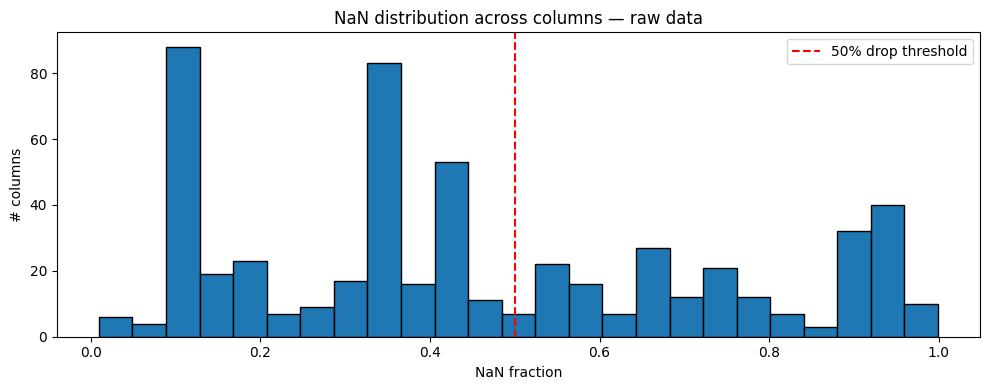

Top 15 highest-NaN columns:
       nan_count  nan_fraction
a3f        83787      0.999165
d9g1       83574      0.996625
d9g2       83527      0.996065
d302       81417      0.970903
d301       81015      0.966109
a23f       80926      0.965048
a23i       80926      0.965048
a22b       80883      0.964535
a177d      80755      0.963008
a166f      80748      0.962925
f33g       80309      0.957690
d304       80285      0.957404
f33f       80086      0.955031
f33h       79777      0.951346
f33d       79602      0.949259


In [5]:
# ── Cell: NaN overview (raw) ──────────────────────────────────────────────────
nan_df = nan_summary(origin_data)
print(f"{len(nan_df)} / {origin_data.shape[1]} columns have at least one NaN\n")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(nan_df["nan_fraction"], bins=25, edgecolor="black")
ax.axvline(0.5, color="red", ls="--", label="50% drop threshold")
ax.set_xlabel("NaN fraction"); ax.set_ylabel("# columns")
ax.set_title("NaN distribution across columns — raw data")
ax.legend(); plt.tight_layout(); plt.show()

print("Top 15 highest-NaN columns:")
print(nan_df.head(15).to_string())

In [6]:
# ── Cell: run preprocessing ───────────────────────────────────────────────────
X, y, sensitive = preprocess(
    origin_data,
    target_col=TARGET,
    nan_threshold=0.5,
    drop_other_scores=True,
)
print(f"\nX : {X.shape}")
print(f"y : {y.shape}  |  classes: {sorted(y.unique())}")
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

2026-06-07 19:38:33 | INFO     | src.data.preprocessor | Input shape: (83857, 561)
2026-06-07 19:38:33 | INFO     | src.data.preprocessor | Step 1: structural drops
2026-06-07 19:38:33 | INFO     | src.data.preprocessor |   Dropping 8 identifier cols
2026-06-07 19:38:33 | INFO     | src.data.preprocessor |   Dropping 6 availability-flag cols
2026-06-07 19:38:34 | INFO     | src.data.preprocessor |   Dropping 28 redundant cols
2026-06-07 19:38:34 | INFO     | src.data.preprocessor | Step 2: row-level NaN filter
2026-06-07 19:38:34 | INFO     | src.data.preprocessor |   Dropped 3734 rows with >90% NaN
2026-06-07 19:38:34 | INFO     | src.data.preprocessor | Step 3: family aggregations
2026-06-07 19:38:35 | INFO     | src.data.preprocessor |   Dropping 37 family-agg-source cols
2026-06-07 19:38:35 | INFO     | src.data.preprocessor | Step 4: teacher aggregations
2026-06-07 19:38:35 | INFO     | src.data.preprocessor |   Dropping 50 teacher-agg-source/dep cols
2026-06-07 19:38:35 | INFO   

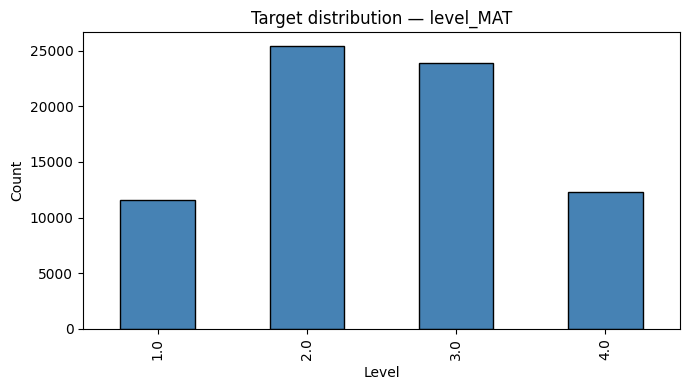

In [7]:
# ── Cell: target distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
y.value_counts().sort_index().plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
ax.set_title(f"Target distribution — {TARGET}")
ax.set_xlabel("Level"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

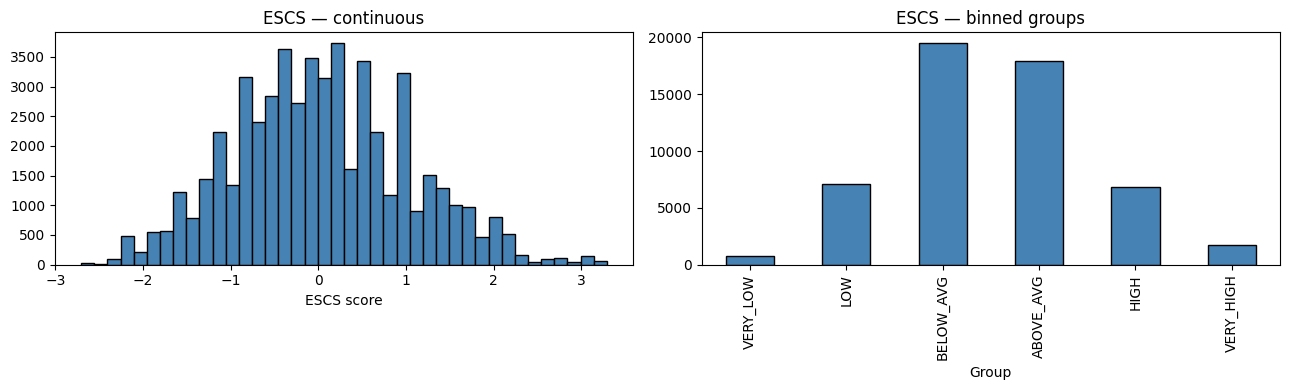

ESCS NaN: 19281 (26.4%)

ESCS group counts:
f_ESCS
VERY_LOW       787
LOW           7122
BELOW_AVG    19473
ABOVE_AVG    17891
HIGH          6842
VERY_HIGH     1756
Name: count, dtype: int64


In [8]:
# ── Cell: ESCS distribution ───────────────────────────────────────────────────
escs_binned = bin_escs(sensitive)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sensitive.dropna(), bins=40, edgecolor="black", color="steelblue")
axes[0].set_title("ESCS — continuous"); axes[0].set_xlabel("ESCS score")

escs_binned.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], edgecolor="black", color="steelblue"
)
axes[1].set_title("ESCS — binned groups"); axes[1].set_xlabel("Group")
plt.tight_layout(); plt.show()

print(f"ESCS NaN: {sensitive.isna().sum()} ({sensitive.isna().mean():.1%})")
print(f"\nESCS group counts:\n{escs_binned.value_counts().sort_index()}")

In [9]:
# ── Cell: sensitive attributes summary ───────────────────────────────────────
sensitive_present = [
    c for c in X.columns
    if c in [
        "f_ESCS", "f_monthly_household_income",
        "f_mother_education_level", "f_father_education_level",
        "f_mother_occupation", "f_father_occupation",
        "f_mother_place_of_birth", "f_student_place_of_birth",
        "f_language_spoken_at_home", "f_type_of_family_unit",
        "s_gender",
    ]
]

print(f"{'Column':<45} {'dtype':<12} {'unique':>6}  {'NaN%':>6}")
print("-" * 75)
for col in sensitive_present:
    print(f"{col:<45} {str(X[col].dtype):<12} {X[col].nunique(dropna=True):>6}  {X[col].isna().mean():>6.1%}")

Column                                        dtype        unique    NaN%
---------------------------------------------------------------------------
s_gender                                      object            2    0.7%
f_mother_education_level                      float64           9   27.8%
f_father_education_level                      float64           9   32.8%
f_mother_place_of_birth                       object            4   29.7%
f_student_place_of_birth                      object            4   27.4%
f_language_spoken_at_home                     object            2   26.6%
f_mother_occupation                           float64           4   30.7%
f_father_occupation                           float64           4   34.8%
f_ESCS                                        float64        3043   26.4%


288 / 291 columns still have NaNs after preprocessing



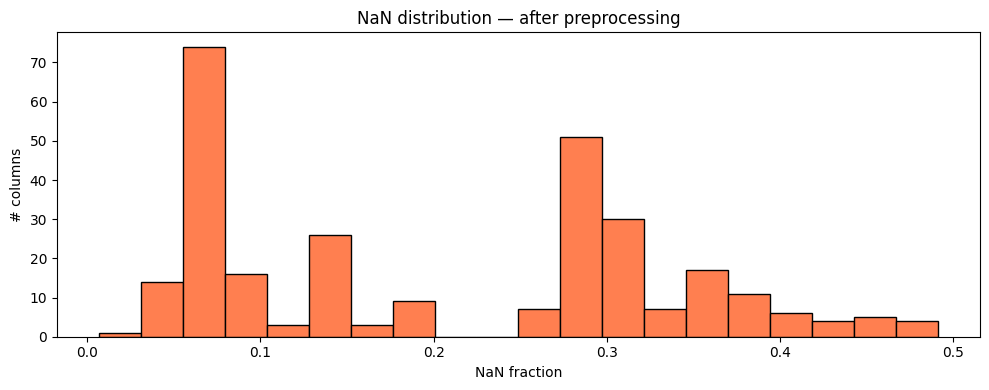

In [10]:
# ── Cell: NaN overview post-preprocessing ────────────────────────────────────
nan_post = nan_summary(X)
print(f"{len(nan_post)} / {X.shape[1]} columns still have NaNs after preprocessing\n")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(nan_post["nan_fraction"], bins=20, edgecolor="black", color="coral")
ax.set_xlabel("NaN fraction"); ax.set_ylabel("# columns")
ax.set_title("NaN distribution — after preprocessing")
plt.tight_layout(); plt.show()

## Imputation

In [11]:
# ── Cell: imputation imports ──────────────────────────────────────────────────
from src.data.imputation import impute, imputation_report, SENSITIVE_COLS

In [12]:
# ── Cell: run imputation ──────────────────────────────────────────────────────
X_imputed, flag_df = impute(X)

print(f"X before : {X.shape}         NaNs: {X.isna().sum().sum()}")
print(f"X after  : {X_imputed.shape} NaNs: {X_imputed.isna().sum().sum()}")
print(f"\nSensitive flag columns added: {list(flag_df.columns)}")

2026-06-07 19:38:39 | INFO     | src.data.imputation |   [FLAG]    s_gender                                      491 NaNs (0.7%)
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [CONT]    a2                                            22536 NaNs → median=2005.000
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [ORD]     a3a                                           27308 NaNs → mode=1
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [ORD]     a3b                                           31052 NaNs → mode=1
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [ORD]     living_with_father_mother                     31530 NaNs → mode=1
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [ORD]     a3c                                           34732 NaNs → mode=1
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [ORD]     s_birth_year                                  9599 NaNs → mode=1
2026-06-07 19:38:39 | INFO     | src.data.imputation |   [ORD]   

In [13]:
# ── Cell: imputation report ───────────────────────────────────────────────────
report = imputation_report(X, X_imputed, flag_df)

print(f"Columns that had NaNs: {len(report)}\n")
print(report.to_string())

Columns that had NaNs: 288

                                        nan_before  nan_after  nan_fraction_before  nan_fraction_after     strategy
a61                                          35941          0             0.491319            0.000000     ord→mode
d9e2                                         34961          0             0.477923            0.000000  cont→median
d9d2                                         34749          0             0.475025            0.000000  cont→median
a3c                                          34732          0             0.474792            0.000000     ord→mode
d9e1                                         34118          0             0.466399            0.000000  cont→median
d9d1                                         33733          0             0.461136            0.000000  cont→median
p7an                                         33398          0             0.456556            0.000000     ord→mode
d10b                                        

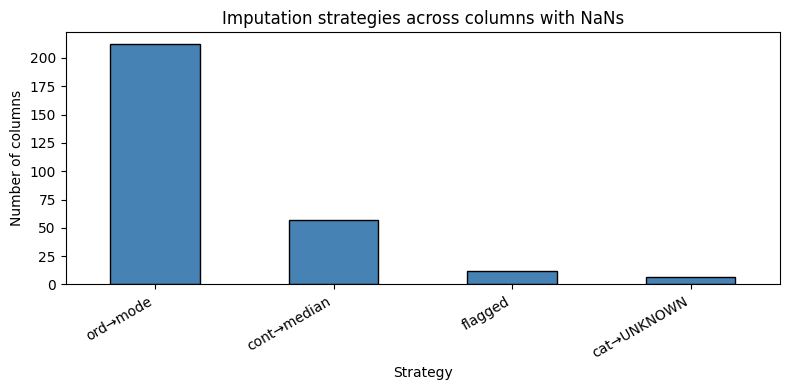

In [14]:
# ── Cell: imputation strategy breakdown ──────────────────────────────────────
strategy_counts = report["strategy"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
strategy_counts.plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
ax.set_title("Imputation strategies across columns with NaNs")
ax.set_xlabel("Strategy")
ax.set_ylabel("Number of columns")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Sensitive attribute missingness:

Flag column                                         # missing   % missing
---------------------------------------------------------------------------
s_gender_was_nan                                          491        0.7%
f_mother_education_level_was_nan                        20352       27.8%
f_father_education_level_was_nan                        24005       32.8%
f_mother_employment_status_was_nan                      21384       29.2%
f_father_employment_status_was_nan                      24898       34.0%
f_mother_place_of_birth_was_nan                         21740       29.7%
f_father_place_of_birth_was_nan                         24270       33.2%
f_student_place_of_birth_was_nan                        20026       27.4%
f_language_spoken_at_home_was_nan                       19484       26.6%
f_mother_occupation_was_nan                             22469       30.7%
f_father_occupation_was_nan                             25475       34.8%
f_

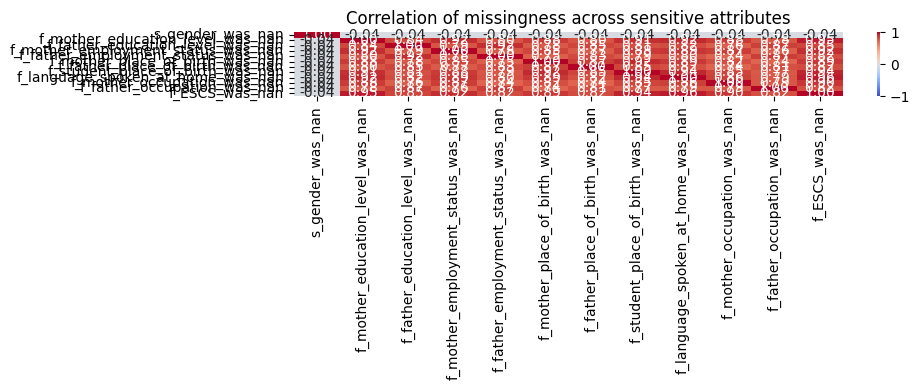

In [15]:
# ── Cell: sensitive attribute NaN flags overview ──────────────────────────────
if flag_df.empty:
    print("No sensitive columns had NaNs.")
else:
    print("Sensitive attribute missingness:\n")
    print(f"{'Flag column':<50} {'# missing':>10}  {'% missing':>10}")
    print("-" * 75)
    for col in flag_df.columns:
        n = flag_df[col].sum()
        print(f"{col:<50} {n:>10}  {n/len(flag_df):>10.1%}")

    # heatmap of co-occurrence of missingness across sensitive cols
    if len(flag_df.columns) > 1:
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.heatmap(
            flag_df.astype(int).corr(),
            annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, vmin=-1, vmax=1,
        )
        ax.set_title("Correlation of missingness across sensitive attributes")
        plt.tight_layout()
        plt.show()

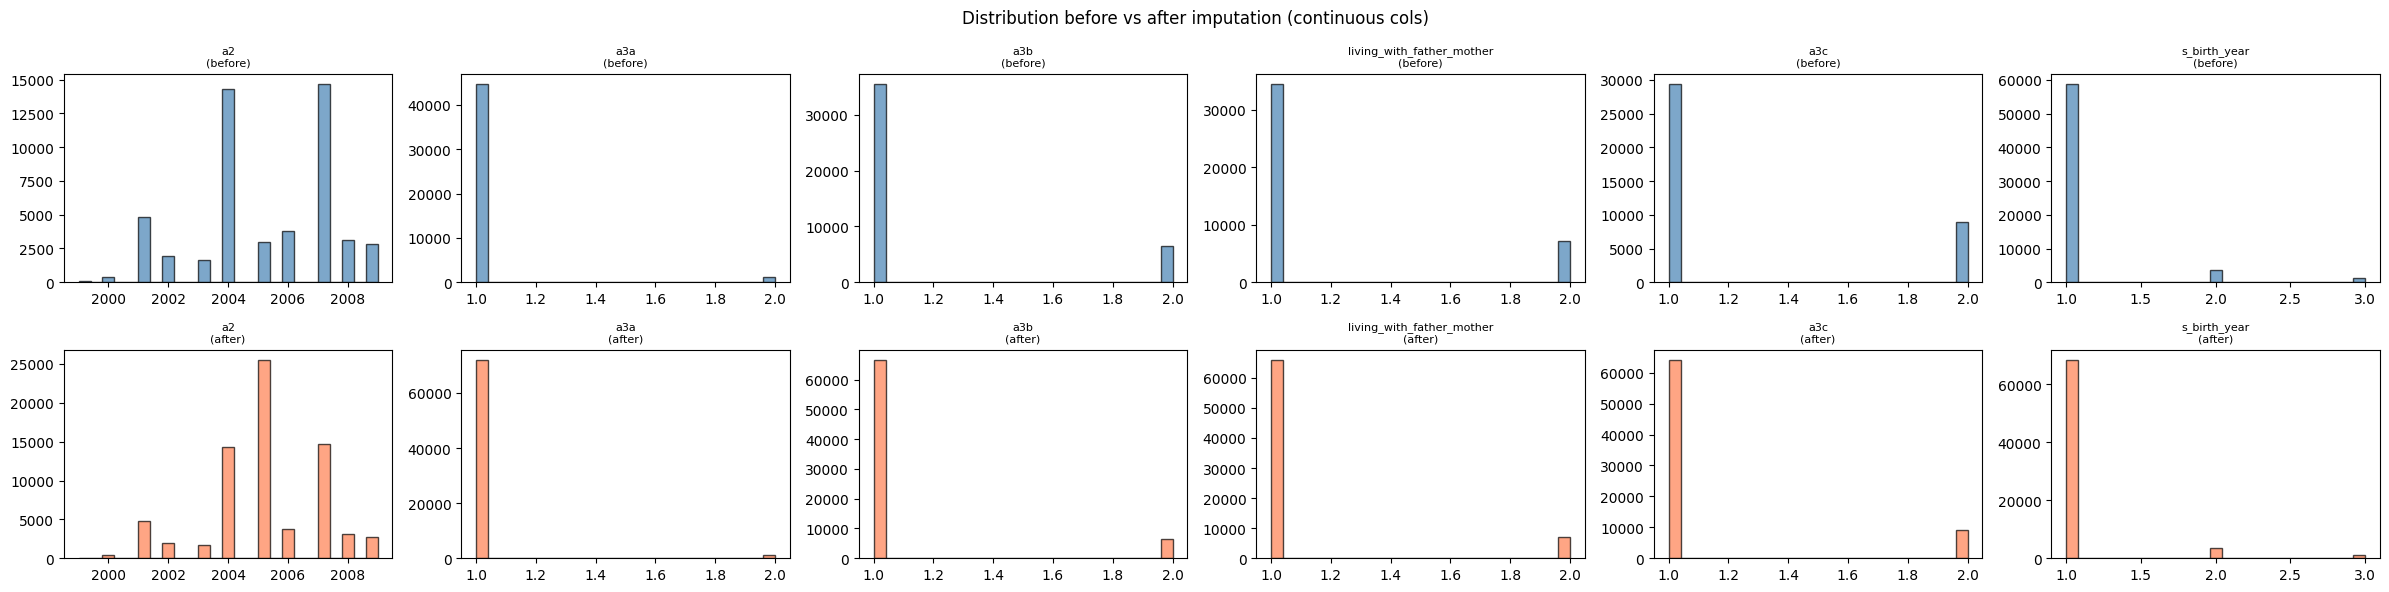

In [16]:
# ── Cell: distribution check — before vs after for continuous cols ────────────
# Pick a few continuous cols to verify imputation didn't shift distributions badly
continuous_cols = [
    c for c in X.columns
    if c not in SENSITIVE_COLS
    and X[c].isna().sum() > 0
    and X[c].dtype in [np.float64, np.int64]
    and not c.startswith("f_")   # skip sensitive-prefixed
][:6]  # cap at 6 for readability

if continuous_cols:
    fig, axes = plt.subplots(2, len(continuous_cols), figsize=(4*len(continuous_cols), 6))
    for i, col in enumerate(continuous_cols):
        axes[0, i].hist(X[col].dropna(), bins=25, edgecolor="black", color="steelblue", alpha=0.7)
        axes[0, i].set_title(f"{col}\n(before)", fontsize=8)
        axes[1, i].hist(X_imputed[col].dropna(), bins=25, edgecolor="black", color="coral", alpha=0.7)
        axes[1, i].set_title(f"{col}\n(after)", fontsize=8)
    plt.suptitle("Distribution before vs after imputation (continuous cols)")
    plt.tight_layout()
    plt.show()

## Statistical Checks

In [ ]:
# ── Cell: sensitive attribute vs target ───────────────────────────────────────
plot_df = X_imputed[sensitive_present].copy()
plot_df[TARGET] = y.values

n_cols = len(sensitive_present)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, sensitive_present):
    if X_imputed[col].dtype == object:
        ct = pd.crosstab(plot_df[col], plot_df[TARGET], normalize="index")
        ct.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm", legend=False)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
    else:
        plot_df.boxplot(column=col, by=TARGET, ax=ax)
        plt.sca(ax)
        plt.title("")

    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=TARGET, loc="upper right", fontsize=8)
plt.suptitle(f"Sensitive attributes vs {TARGET}", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell: ESCS vs target (dedicated — most important sensitive attr) ───────────
if "f_ESCS" in X_imputed.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # left: boxplot of ESCS per target class
    plot_df2 = pd.DataFrame({"f_ESCS": X_imputed["f_ESCS"].values, TARGET: y.values})
    plot_df2.boxplot(column="f_ESCS", by=TARGET, ax=axes[0])
    axes[0].set_title("ESCS distribution per target class")
    axes[0].set_xlabel(TARGET)
    axes[0].set_ylabel("ESCS")
    plt.sca(axes[0]); plt.title("ESCS per target class")

    # right: mean ESCS per target class with error bars
    
    means  = plot_df2.groupby(TARGET)["f_ESCS"].mean()
    stds   = plot_df2.groupby(TARGET)["f_ESCS"].std()
    axes[1].bar(means.index, means.values, yerr=stds.values,
                edgecolor="black", color="steelblue", capsize=4)
    axes[1].set_title("Mean ESCS per target class (±1 std)")
    axes[1].set_xlabel(TARGET)
    axes[1].set_ylabel("Mean ESCS")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    print("Mean ESCS per target class:")
    print(plot_df2.groupby(TARGET)["f_ESCS"].agg(["mean", "std", "count"]).round(3))    

In [ ]:
# ── Cell: correlation heatmap — sensitive attrs vs target (numerical encoding) ─
from sklearn.preprocessing import OrdinalEncoder

encode_df = X_imputed[sensitive_present].copy()
encode_df[TARGET] = y.values

# ordinal-encode categoricals for correlation purposes only
cat_cols = encode_df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encode_df[cat_cols] = enc.fit_transform(encode_df[cat_cols])

encode_df = encode_df.apply(pd.to_numeric, errors="coerce")
corr = encode_df.corr()[[TARGET]].drop(TARGET)

fig, ax = plt.subplots(figsize=(4, len(sensitive_present) * 0.5 + 1))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=ax, linewidths=0.5,
)
ax.set_title(f"Correlation of sensitive attributes with {TARGET}")
plt.tight_layout()
plt.show()

## Save

In [ ]:
# ── Cell: train/test split ────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

TRAIN_PATH = cfg["paths"]["train_data"]
TEST_PATH  = cfg["paths"]["test_data"]

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"\nClass balance (train):\n{y_train.value_counts(normalize=True).sort_index().round(3)}")
print(f"\nClass balance (test):\n{y_test.value_counts(normalize=True).sort_index().round(3)}")

# ESCS distribution across splits
if "f_ESCS" in X_train.columns:
    escs_train = bin_escs(X_train["f_ESCS"])
    escs_test  = bin_escs(X_test["f_ESCS"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    escs_train.value_counts().sort_index().plot(
        kind="bar", ax=axes[0], edgecolor="black", color="steelblue"
    )
    axes[0].set_title("ESCS groups — train")

    escs_test.value_counts().sort_index().plot(
        kind="bar", ax=axes[1], edgecolor="black", color="coral"
    )
    axes[1].set_title("ESCS groups — test")
    plt.suptitle("ESCS distribution across splits")
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Cell: save train / test / processed ───────────────────────────────────────
for path in [TRAIN_PATH, TEST_PATH, PROC_PATH]:
    os.makedirs(os.path.dirname(path), exist_ok=True)

# full processed dataset (features + flags + target)
final_df = X_imputed.copy()
if not flag_df.empty:
    final_df = pd.concat([final_df, flag_df], axis=1)
final_df[TARGET] = y
final_df.to_csv(PROC_PATH, index=False)

# train split
train_df = X_train.copy()
if not flag_df.empty:
    train_df = pd.concat([train_df, flag_df.loc[X_train.index]], axis=1)
train_df[TARGET] = y_train
train_df.to_csv(TRAIN_PATH, index=False)

# test split
test_df = X_test.copy()
if not flag_df.empty:
    test_df = pd.concat([test_df, flag_df.loc[X_test.index]], axis=1)
test_df[TARGET] = y_test
test_df.to_csv(TEST_PATH, index=False)

print(f"Saved processed → {PROC_PATH}  |  shape: {final_df.shape}")
print(f"Saved train     → {TRAIN_PATH}  |  shape: {train_df.shape}")
print(f"Saved test      → {TEST_PATH}   |  shape: {test_df.shape}")

In [17]:
if False:
    # ── Cell: save imputed data ───────────────────────────────────────────────────
    import os

    # Attach flags and target to imputed X
    final_df = X_imputed.copy()
    if not flag_df.empty:
        final_df = pd.concat([final_df, flag_df], axis=1)
    final_df[TARGET] = y

    os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
    final_df.to_csv(PROC_PATH, index=False)
    print(f"Saved → {PROC_PATH}  |  shape: {final_df.shape}")
    print(f"  Feature cols    : {X_imputed.shape[1]}")
    print(f"  Flag cols       : {flag_df.shape[1] if not flag_df.empty else 0}")
    print(f"  Target col      : 1")